<a href="https://colab.research.google.com/github/Eswa2020/urban-parking-prediction-models/blob/master/notebooks/Melbourne/01_melbourne_data_preparation_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries and loading dataset

In [1]:
#importimg our libraries to use
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
%matplotlib inline

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#let's load the  dataset
dataq=pd.read_csv("/content/drive/MyDrive/melbourne_parking_data.csv",encoding='ISO-8859-1')
dataq.head(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,17176,02/15/2019 07:45:29 PM,02/15/2019 07:46:52 PM,1,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,False,True
1,17176,03/25/2019 08:35:40 PM,03/25/2019 08:39:08 PM,4,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,False,True


In [4]:
dataq.tail(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
1048573,17418,05/15/2019 04:31:54 PM,05/15/2019 04:32:56 PM,1,13397W,430.0,1/4P M-F 16:00-18:30,Docklands,1383,VILLAGE STREET,131,BRENTANI WAY,974,MCCRAE STREET,5,W,West,6320,False,False
1048574,17418,05/25/2019 06:10:25 PM,05/25/2019 06:18:14 PM,8,13397W,362.0,1P SAT-SUN 7:30-18:30,Docklands,1383,VILLAGE STREET,131,BRENTANI WAY,974,MCCRAE STREET,5,W,West,6320,False,True


The dataset contains parking sensor records from 2019 and appears to be concentrated in Docklands, Melbourne, Australia

## Exploring our dataset

In [5]:
#We have about 1,048 ,575 rows and 20 columns.
# The dataset contains over 1.04 million valid parking records, which is large enough for robust temporal and operational analysis.
dataq.shape

(1048575, 20)

In [6]:
#We check if we have any null values in our columns
#sign plate has like 20% which is expected behaviour
dataq.isna().sum()

,0
DeviceId,0
ArrivalTime,0
DepartureTime,0
DurationMinutes,0
StreetMarker,0
SignPlateID,286382
Sign,286382
AreaName,1
StreetId,0
StreetName,0


In [7]:
#W have like 407 duplicates...should recheck thsi
dataq.duplicated().sum()

np.int64(407)

In [8]:
#We have several interger columns none seems to be out of place
#we have 2 categorical(and also potential target variables "vehicle present and Inviolation")
dataq.dtypes


,0
DeviceId,int64
ArrivalTime,object
DepartureTime,object
DurationMinutes,int64
StreetMarker,object
SignPlateID,float64
Sign,object
AreaName,object
StreetId,int64
StreetName,object


In [9]:
#WE have 8 columns that are intergers
descriptive_stats = dataq.describe()
print(descriptive_stats)

           DeviceId  DurationMinutes    SignPlateID      StreetId  \
count  1.048575e+06     1.048575e+06  762193.000000  1.048575e+06   
mean   1.731886e+04     4.799476e+01     285.859107  5.186585e+02   
std    2.998304e+02     9.260124e+01     158.747030  3.813933e+02   
min    1.003600e+04     0.000000e+00       3.000000  5.000000e+00   
25%    1.725800e+04     3.000000e+00     196.000000  1.230000e+02   
50%    1.731300e+04     1.200000e+01     285.000000  5.280000e+02   
75%    1.736800e+04     4.600000e+01     421.000000  7.530000e+02   
max    2.842100e+04     1.440000e+03     715.000000  1.497000e+03   

       BetweenStreet1ID  BetweenStreet2ID  SideOfStreet         BayId  
count      1.048575e+06      1.048575e+06  1.048575e+06  1.048575e+06  
mean       6.465055e+02      6.902358e+02  3.344938e+00  6.236924e+03  
std        4.197601e+02      5.153619e+02  1.092222e+00  2.275697e+02  
min        5.000000e+00      5.000000e+00  1.000000e+00  5.690000e+02  
25%        1.23000

In [10]:
# DurationMinutes has a mean of about 48 minutes, indicating that the average parking event lasts less than one hour.
# The median duration is 12 minutes, which is much lower than the mean and suggests a strongly right-skewed distribution.
# The standard deviation of about 92.6 minutes shows substantial variation in parking duration across events.
# The minimum duration is 0 minutes, which may reflect very short stays, sensor noise, or recording artefacts.
# The 25th percentile is 3 minutes, meaning that a quarter of all parking events are extremely short.
# The 75th percentile is 46 minutes, meaning that most parking events are under one hour in duration.
# The maximum duration is 1,440 minutes, indicating the presence of very long stays or potential outliers in the dataset.

In [ ]:
descriptive_stats .to_csv('results.csv', index=False)

In [12]:
# VehiclePresent frequency shows how often bays are recorded as occupied versus unoccupied in the dataset.
# InViolation frequency shows how often parking events are recorded as violating parking rules.
# These distributions help assess class balance before any classification or operational analysis.

vehicle_status_freq = dataq['VehiclePresent'].value_counts()
in_violation_freq = dataq['InViolation'].value_counts()

print("Vehicle Presence Frequency:")
print(vehicle_status_freq)

print("\nIn Violation Frequency:")
print(in_violation_freq)

Vehicle Presence Frequency:
VehiclePresent
True     537207
False    511368
Name: count, dtype: int64

In Violation Frequency:
InViolation
False    993420
True      55155
Name: count, dtype: int64


In [ ]:
# VehiclePresent is fairly balanced, with 537,207 True values and 511,368 False values, indicating a near-even split between occupied and unoccupied observations.
# InViolation is strongly skewed toward non-violations, with 993,420 False values versus 55,155 True values, indicating that parking violations are relatively rare events in the dataset.


##Cleaning Data

In [13]:
# Data cleaning prepares the raw parking records for reliable analysis and modeling.
# This step removes duplicates, fixes datetime fields, checks missing values, and standardizes key variables.

In [14]:
# Create a working copy to avoid changing the original dataset.
df = dataq.copy()


In [15]:
# Check dataset shape before cleaning.
print("Initial shape:", df.shape)

Initial shape: (1048575, 20)


In [16]:
# Remove duplicate records to avoid repeated parking events influencing the analysis.
df = df.drop_duplicates()

In [17]:
# Convert datetime columns into proper datetime format for time-based analysis.
df["ArrivalTime"] = pd.to_datetime(df["ArrivalTime"], errors="coerce")
df["DepartureTime"] = pd.to_datetime(df["DepartureTime"], errors="coerce")

/tmp/ipykernel_1475/2302069356.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ArrivalTime"] = pd.to_datetime(df["ArrivalTime"], errors="coerce")
/tmp/ipykernel_1475/2302069356.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DepartureTime"] = pd.to_datetime(df["DepartureTime"], errors="coerce")


In [18]:
# Check missing values in the main variables used for analysis.
missing_summary = df[[
    "ArrivalTime", "DepartureTime", "DurationMinutes",
    "AreaName", "StreetName", "BayId", "VehiclePresent", "InViolation"
]].isnull().sum()

print("\nMissing values in key columns:")
print(missing_summary)


Missing values in key columns:
ArrivalTime        0
DepartureTime      0
DurationMinutes    0
AreaName           1
StreetName         0
BayId              0
VehiclePresent     0
InViolation        0
dtype: int64


In [19]:
# Drop rows with missing values in essential analytical fields.
df = df.dropna(subset=[
    "ArrivalTime", "DepartureTime", "DurationMinutes",
    "AreaName", "BayId", "VehiclePresent", "InViolation"
])

In [20]:
# Keep only non-negative durations because negative parking time is not valid.
df = df[df["DurationMinutes"] >= 0]

In [21]:
# Convert boolean status fields into integer form for easier aggregation and modeling.
df["VehiclePresent"] = df["VehiclePresent"].astype(int)
df["InViolation"] = df["InViolation"].astype(int)

In [22]:
# Check dataset shape after cleaning.
print("\nCleaned shape:", df.shape)

# Display data types after cleaning.
print("\nData types after cleaning:")
print(df.dtypes)



Cleaned shape: (1048167, 20)

Data types after cleaning:
DeviceId                     int64
ArrivalTime         datetime64[ns]
DepartureTime       datetime64[ns]
DurationMinutes              int64
StreetMarker                object
SignPlateID                float64
Sign                        object
AreaName                    object
StreetId                     int64
StreetName                  object
BetweenStreet1ID             int64
BetweenStreet1              object
BetweenStreet2ID             int64
BetweenStreet2              object
SideOfStreet                 int64
SideOfStreetCode            object
SideName                    object
BayId                        int64
InViolation                  int64
VehiclePresent               int64
dtype: object


In [23]:
# Preview the cleaned dataset.
df.head(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,17176,2019-02-15 19:45:29,2019-02-15 19:46:52,1,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,0,1
1,17176,2019-03-25 20:35:40,2019-03-25 20:39:08,4,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,0,1


##Feature Enginnering

 **Feature Engineering Explanation**

The original parking records were transformed into analysis-ready variables to capture temporal, operational, and contextual parking patterns. Timestamp fields were converted into structured time features such as date, month, day of week, arrival hour, and day type, allowing the analysis to compare weekday, weekend, and within-day dynamics. Additional derived variables such as season, time of day, and peak-hour indicators were created to reflect recurring urban activity cycles. Boolean operational fields, including vehicle presence and parking violation status, were also standardized for aggregation and later modeling. Together, these engineered features allow the dataset to move beyond raw event logs and support both descriptive and predictive parking analysis.

In [24]:
# Exploratory data analysis is used to understand the distribution, timing, and operational patterns of parking activity.
# This step helps identify skewness, temporal trends, class balance, and area-level variation before modeling.

import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Create core temporal features for exploratory analysis.
df["date"] = df["ArrivalTime"].dt.date
df["month"] = df["ArrivalTime"].dt.month
df["day_of_week"] = df["ArrivalTime"].dt.day_name()
df["arrival_hour"] = df["ArrivalTime"].dt.hour


In [26]:
# Create a weekday/weekend variable for clearer operational comparison.
df["day_type"] = np.where(df["ArrivalTime"].dt.dayofweek >= 5, "Weekend", "Weekday")

In [27]:
# Create a season variable using Australian seasonal grouping.
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

df["season"] = df["month"].apply(get_season)

##EDA

Parking duration is strongly right-skewed, with a mean of about 48 minutes but a median of only 12 minutes, indicating that most parking sessions are short while a smaller number of long stays increase the average.

In [28]:
# Summary statistics for duration.
print("Duration summary:")
print(df["DurationMinutes"].describe())


Duration summary:
count    1.048167e+06
mean     4.801154e+01
std      9.260531e+01
min      0.000000e+00
25%      3.000000e+00
50%      1.200000e+01
75%      4.600000e+01
max      1.440000e+03
Name: DurationMinutes, dtype: float64


The occupancy variable is relatively balanced, which makes it suitable for direct operational analysis, whereas violations are much less frequent and should be treated as a rare-event process in later interpretation.

In [29]:
# Frequency of occupancy and violation variables.
print("\nVehicle presence frequency:")
print(df["VehiclePresent"].value_counts())

print("\nViolation frequency:")
print(df["InViolation"].value_counts())



Vehicle presence frequency:
VehiclePresent
1    536856
0    511311
Name: count, dtype: int64

Violation frequency:
InViolation
0    993012
1     55155
Name: count, dtype: int64


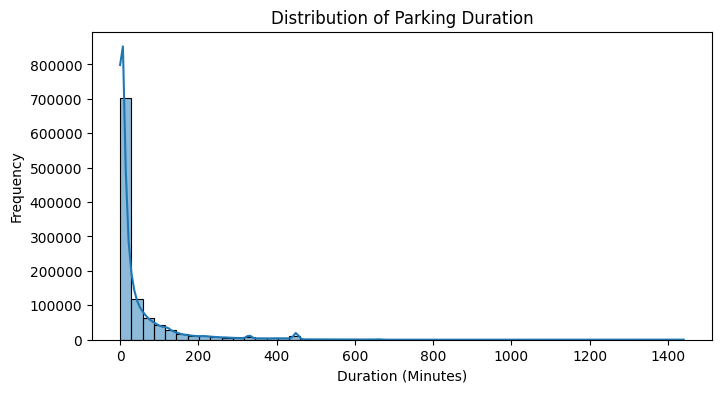

In [30]:
# Plot the distribution of parking duration.
plt.figure(figsize=(8, 4))
sns.histplot(df["DurationMinutes"], bins=50, kde=True)
plt.title("Distribution of Parking Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

Average parking duration varies by arrival hour, suggesting that within-day temporal structure is important and that hour of arrival is a meaningful explanatory feature


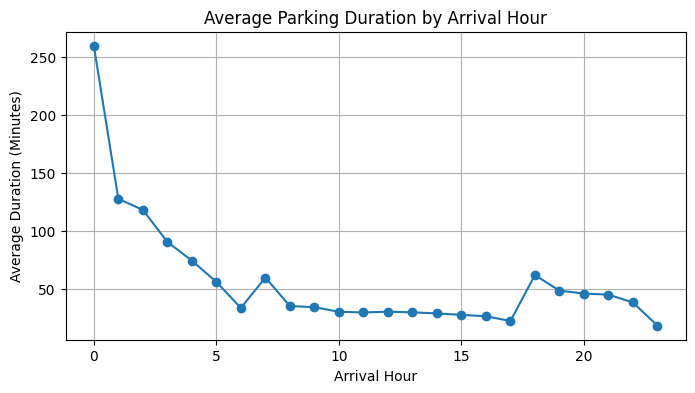

In [31]:
# Plot average duration by hour of arrival.
hourly_duration = df.groupby("arrival_hour")["DurationMinutes"].mean()

plt.figure(figsize=(8, 4))
hourly_duration.plot(marker="o")
plt.title("Average Parking Duration by Arrival Hour")
plt.xlabel("Arrival Hour")
plt.ylabel("Average Duration (Minutes)")
plt.grid(True)
plt.show()

Parking activity differs across days of the week, indicating that routine urban schedules influence demand and parking pressure.

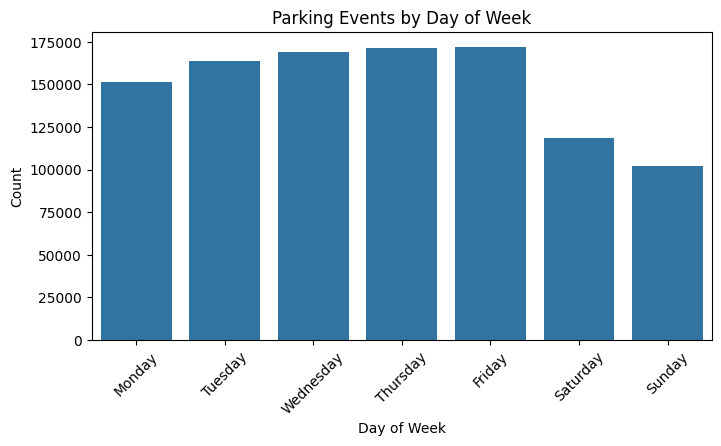

In [32]:
# Plot number of parking events by day of week.
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="day_of_week", order=day_order)
plt.title("Parking Events by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Variation across weekday versus weekend periods and across seasonal groupings suggests that parking dynamics are influenced by broader temporal cycles rather than random fluctuation alone.

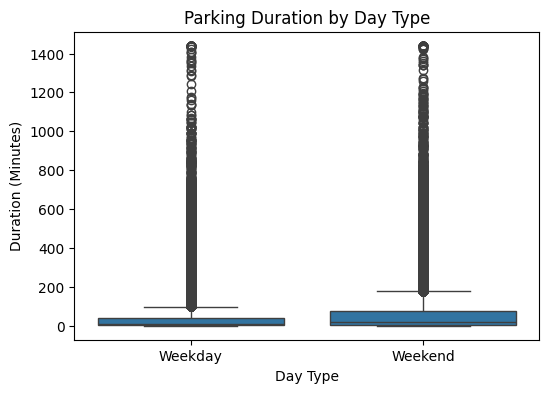

In [33]:
# Plot average duration by day type.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="day_type", y="DurationMinutes")
plt.title("Parking Duration by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Duration (Minutes)")
plt.show()

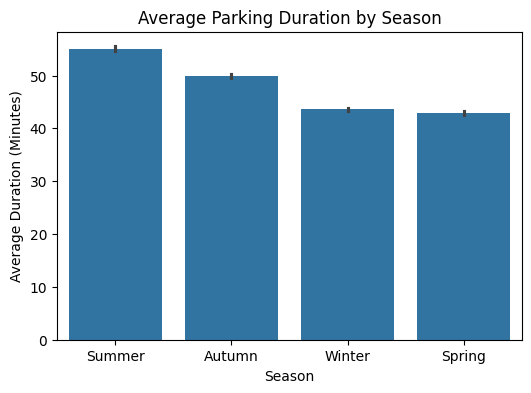

In [34]:
# Plot average parking duration by season.
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="season", y="DurationMinutes", order=["Summer", "Autumn", "Winter", "Spring"])
plt.title("Average Parking Duration by Season")
plt.xlabel("Season")
plt.ylabel("Average Duration (Minutes)")
plt.show()

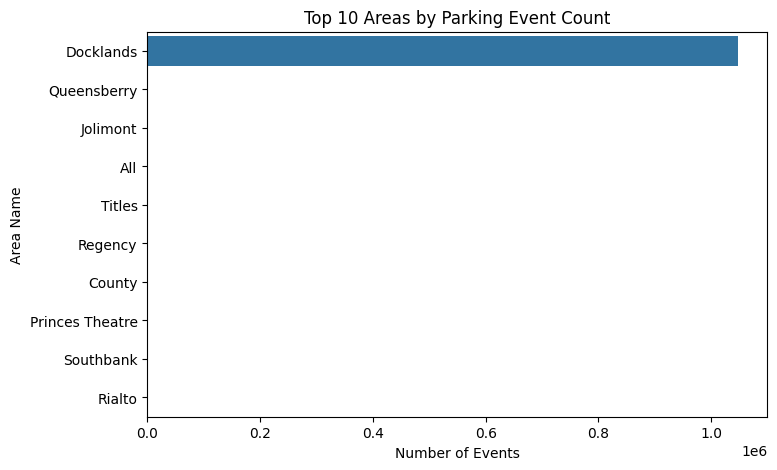

In [35]:
# Identify the top 10 areas by number of parking events.
top_areas = df["AreaName"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_areas.values, y=top_areas.index)
plt.title("Top 10 Areas by Parking Event Count")
plt.xlabel("Number of Events")
plt.ylabel("Area Name")
plt.show()

## Spatial Analysis

Parking activity is heavily concentrated in Docklands, with a small number of streets accounting for most observed events, so the project is best interpreted as a Docklands-focused operational parking study rather than a citywide Melbourne analysis.

In [ ]:
# Spatial summary analysis is used to identify which areas and streets dominate parking activity, duration, and violations before moving to formal modeling.

In [36]:
# Area-level parking activity
area_summary = df.groupby("AreaName").agg(
    total_events=("BayId", "count"),
    mean_duration=("DurationMinutes", "mean"),
    occupancy_rate=("VehiclePresent", "mean"),
    violation_rate=("InViolation", "mean")
).sort_values("total_events", ascending=False)

area_summary.head(10)

,total_events,mean_duration,occupancy_rate,violation_rate
AreaName,,,,
Docklands,1046965,48.007337,0.512187,0.052652
Queensberry,116,87.068966,0.448276,0.008621
Jolimont,72,62.166667,0.444444,0.027778
All,67,74.179104,0.462687,0.059701
Titles,64,48.875000,0.515625,0.046875
Regency,59,42.694915,0.440678,0.000000
County,55,27.218182,0.600000,0.036364
Princes Theatre,53,38.792453,0.547170,0.000000
Southbank,52,97.096154,0.403846,0.000000


Street-level summaries show that Bourke Street, Harbour Esplanade, Collins Street, and Batmans Hill Drive dominate the observed parking activity, indicating that parking demand is spatially concentrated rather than evenly distributed across the study ar

In [37]:
# Street-level parking activity
street_summary = df.groupby("StreetName").agg(
    total_events=("BayId", "count"),
    mean_duration=("DurationMinutes", "mean"),
    occupancy_rate=("VehiclePresent", "mean"),
    violation_rate=("InViolation", "mean")
).sort_values("total_events", ascending=False)

street_summary.head(10)

,total_events,mean_duration,occupancy_rate,violation_rate
StreetName,,,,
BOURKE STREET,295866,45.224551,0.510525,0.046812
HARBOUR ESPLANADE,249469,56.803102,0.504953,0.045753
COLLINS STREET,169395,40.626518,0.516231,0.052186
BATMANS HILL DRIVE,114214,46.612963,0.512301,0.052647
MERCHANT STREET,67976,43.811728,0.508827,0.012622
LA TROBE STREET,38013,39.732013,0.509536,0.107805
SEAFARER LANE,37861,30.360714,0.518211,0.078445
VILLAGE STREET,23198,56.634020,0.532934,0.123114
MCCRAE STREET,19873,50.664822,0.552357,0.131485


The dataset is overwhelmingly concentrated in Docklands, with similar occupancy rates to the rest of the observed areas but a higher violation rate, reinforcing the choice to frame subsequent modeling at the Docklands street level.

In [38]:
# Compare Docklands with other areas
docklands_vs_rest = df.assign(
    docklands_flag=np.where(df["AreaName"].str.contains("Docklands", case=False, na=False), "Docklands", "Other Areas")
).groupby("docklands_flag").agg(
    total_events=("BayId", "count"),
    mean_duration=("DurationMinutes", "mean"),
    occupancy_rate=("VehiclePresent", "mean"),
    violation_rate=("InViolation", "mean")
)

docklands_vs_rest

,total_events,mean_duration,occupancy_rate,violation_rate
docklands_flag,,,,
Docklands,1046965,48.007337,0.512187,0.052652
Other Areas,1202,51.672213,0.510815,0.024958


In [ ]:
#dataset is overwhelmingly Docklands-centered, with about 1,046,965 records from Docklands versus only about 1,202 from all other areas combined.
#Street activity is also concentrated on a small set of streets, especially Bourke Street, Harbour Esplanade, Collins Street, and Batmans Hill Drive. #Occupancy rates are fairly similar between Docklands and the rest, but Docklands has a noticeably higher violation rate.
#That means the project should be framed as a Docklands-dominant Melbourne parking dynamics study, not a fully citywide Melbourne study.

##Summary of Descriptive Results and Exploratory Insights

###Main EDA Findings

The exploratory analysis shows that parking duration is highly skewed, with most stays being short but a minority of very long stays increasing the overall mean. Occupancy status is relatively balanced, making it suitable for operational modeling, while parking violations are comparatively rare. Temporal patterns across hour of day, weekday structure, and seasonal grouping indicate that parking behavior follows recurring urban rhythms. Spatial summaries further show that the dataset is overwhelmingly concentrated in Docklands, with a small number of streets dominating observed parking activity. These findings justify a Docklands-focused analytical strategy and support the use of temporal, operational, and street-level features in later modeling.

###Descriptive Interpretation

The engineered dataset captures both temporal and operational structure in parking behavior. Descriptive statistics show that parking duration is highly right-skewed, with most sessions being short and a smaller number of long stays increasing the mean. Occupancy is relatively balanced, whereas parking violations are rare, which has implications for later model interpretation.

###Exploratory Interpretation

The exploratory analysis suggests that parking behavior is shaped by recurring temporal rhythms and localized street-level concentration. Hour of day, weekday structure, and seasonal grouping all appear relevant, while the spatial summaries indicate that the observed system is heavily concentrated in Docklands rather than representing Melbourne uniformly.